# HECATE
HarvEsting loCAl specTra with Exoplanets

In [ ]:
import numpy as np

from HECATE.HECATE import HECATE

from HECATE.get_data import *
from HECATE.plots import *

In [2]:
stellar_params = {
                "Teff":4969, "Teff_err":43,   #effective temperature [K]
                "logg":4.60, "logg_err":0.01, #superficial gravity [dex]
                "FeH":-0.07, "FeH_err":0.02,  #metallicity [dex]
                "P_rot":2.21857312,           #rotation period [d]
                "R_star":0.766,               #radius [solar radii]
                "inc_star":71.87              #stellar inclination [º]
                }

planet_params = {
                "P_orb":2.21857312,           #orbital period [d]
                "a_R":8.76863,                #system scale [stellar radii]
                "Rp_Rs":0.1602,               #planet-to-star radius ratio 
                "t0":53988.30339,             #mid-transit time [d]
                "e":0,                        #orbital eccentricity
                "w":90,                       #argument of periastron [º]
                "inc_planet":85.465,          #planet inclination [º]
                "lbda":-1.00,                 #spin-orbit angle [º]
                "dfp": -0.002424              #mid-transit phase shift
                }

# White light CCF

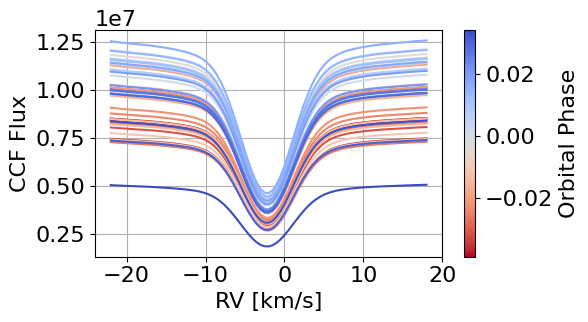

In [ ]:
CCFs, time, airmass, berv, bervmax, snr, list_ccfs = get_CCFs(planet_params, 
                                                              day='2021-08-11', 
                                                              directory_path="HD189733_ESPRESSO_white_light_ccfs")

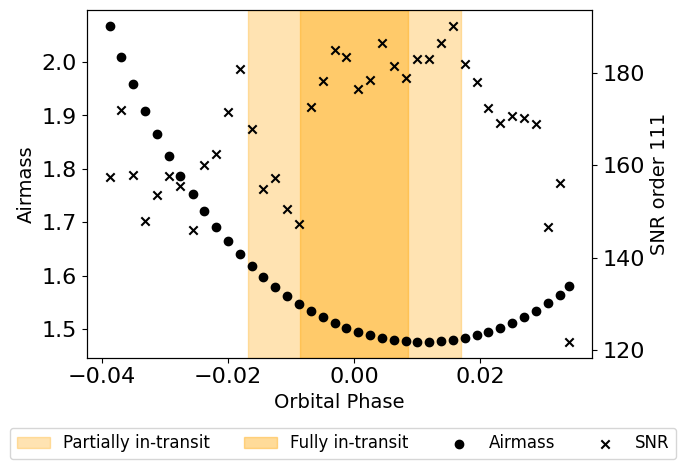

In [4]:
plot_air_snr(planet_params, time, airmass, snr)

In [ ]:
hecate = HECATE(planet_params, stellar_params, time, CCFs, None)

In [ ]:
plot = {"SOAP":False, "fits_initial_CCF":False, 
        "sys_vel_ccf":False, "avg_out_of_transit_CCF":False, 
        "local_CCFs":True, "photometrical_rescale":False}

ccf_type = "white light"
model_fit = "modified Gaussian"

In [ ]:
local_CCFs, CCFs_flux_corr, CCFs_sub_all, avg_out_of_transit_CCF = hecate.extract_local_CCF(model_fit, plot, save=None)

In [ ]:
master_results = hecate.get_profile_parameters(profiles=avg_out_of_transit_CCF, 
                                               data_type="CCF", 
                                               observation_type="master", 
                                               model="modified Gaussian", 
                                               print_output=True, 
                                               plot_fit=True)

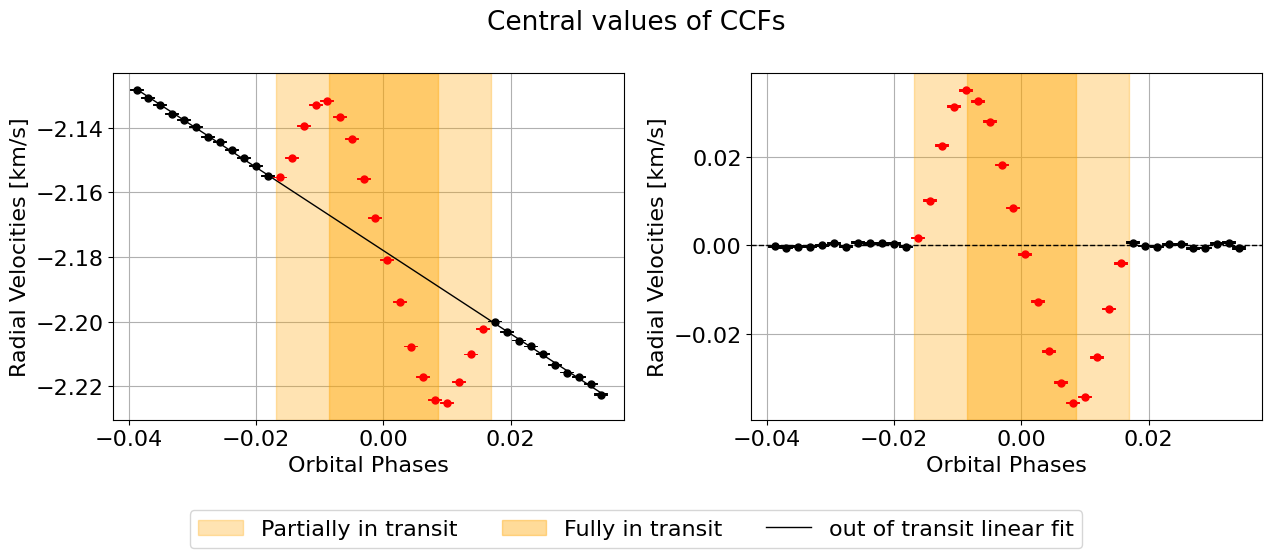

In [ ]:
local_results = hecate.get_profile_parameters(profiles=local_CCFs, 
                                              data_type="CCF", 
                                              observation_type="local", 
                                              model="modified Gaussian", 
                                              print_output=False, 
                                              plot_fit=False)

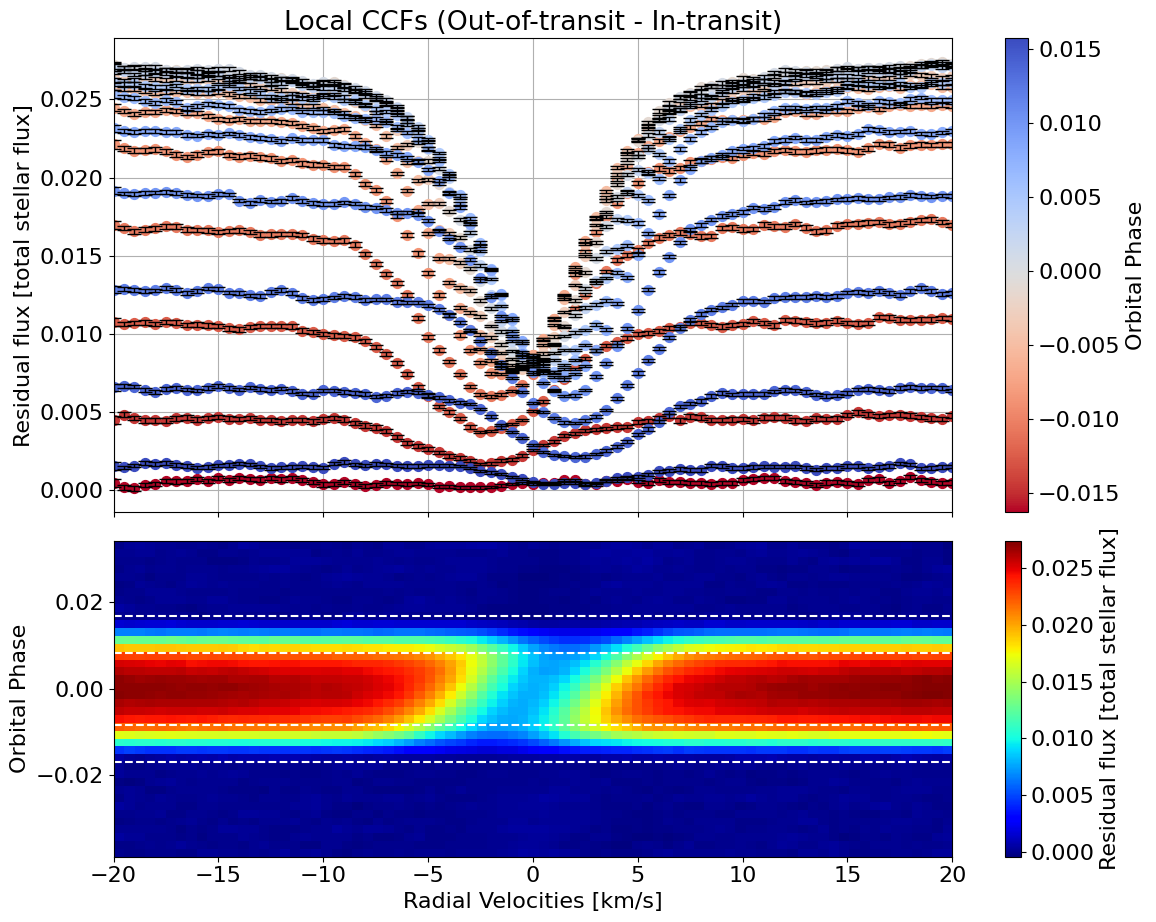

In [ ]:
indices_final = np.where(local_results['R2'] >= 0.95)[0]

local_params = [local_results['central_rv'], local_results['width'], local_results['intensity']]
master_params = [master_results['central_rv'], master_results['width'], master_results['intensity']]

hecate.plot_local_params(indices_final, local_params, master_params, suptitle=r"Local white light CCF parameters")

Central Radial Velocity [km/s]
----------------------------------------
Orbital phases


17898it [00:14, 1214.98it/s, batch: 6 | bound: 3 | nc: 1 | ncall: 366746 | eff(%):  4.738 | loglstar: 33.682 < 38.649 < 37.615 | logz: 22.814 +/-  0.109 | stop:  0.979]             
14110it [00:08, 1592.51it/s, batch: 7 | bound: 4 | nc: 1 | ncall: 267848 | eff(%):  5.069 | loglstar: -21.395 < -15.860 < -16.529 | logz: -22.729 +/-  0.066 | stop:  0.960]        


------------------------------
Linear vs Constant
logZ(linear)   = 22.806 ± 0.102
logZ(constant) = -22.732 ± 0.061
log Bayes factor = 45.538
Unconstrained model favored.
------------------------------


18248it [00:13, 1353.21it/s, batch: 7 | bound: 4 | nc: 1 | ncall: 374386 | eff(%):  4.735 | loglstar: 33.395 < 38.648 < 38.196 | logz: 23.902 +/-  0.105 | stop:  0.910]             
16862it [00:11, 1523.67it/s, batch: 6 | bound: 5 | nc: 1 | ncall: 341839 | eff(%):  4.779 | loglstar: -21.905 < -14.607 < -16.359 | logz: -25.915 +/-  0.088 | stop:  0.849]         


Positive vs Negative slope
logZ(m>0)  = 23.893 ± 0.095
logZ(m<0)  = -25.890 ± 0.081
log Bayes factor = -49.782
Positive slope favored.
Linear fit parameters:
m = 163.035428 +/- 2.507326
b = -0.039822 +/- 0.006069
ln_f = -2.802218 +/- 0.230381
------------------------------
Line-width measure [km/s]
----------------------------------------
$\mu$


...

------------------------------
Linear vs Constant
logZ(linear)   = 18.893 ± 0.106
logZ(constant) = 21.282 ± 0.078
log Bayes factor = -2.389
Zero-slope model favored
Linear fit parameters:
b = 3.057720 +/- 0.016701
ln_f = -3.940960 +/- 0.227853
------------------------------
Line-center intensity [%]
----------------------------------------
$\mu$


17237it [00:12, 1348.63it/s, batch: 7 | bound: 4 | nc: 1 | ncall: 350114 | eff(%):  4.773 | loglstar: -11.695 < -6.136 < -6.801 | logz: -18.428 +/-  0.093 | stop:  0.893]           
15653it [00:10, 1461.91it/s, batch: 8 | bound: 3 | nc: 1 | ncall: 301498 | eff(%):  5.017 | loglstar: -23.376 < -18.192 < -18.695 | logz: -25.887 +/-  0.067 | stop:  0.872]        


------------------------------
Linear vs Constant
logZ(linear)   = -18.434 ± 0.085
logZ(constant) = -25.885 ± 0.063
log Bayes factor = 7.451
Unconstrained model favored.
------------------------------


15752it [00:10, 1490.99it/s, batch: 5 | bound: 4 | nc: 1 | ncall: 317192 | eff(%):  4.800 | loglstar: -23.898 < -18.230 < -19.182 | logz: -30.169 +/-  0.099 | stop:  0.945]         
16846it [00:11, 1465.55it/s, batch: 7 | bound: 4 | nc: 1 | ncall: 342059 | eff(%):  4.771 | loglstar: -11.782 < -6.143 < -6.749 | logz: -17.585 +/-  0.090 | stop:  0.889]          


Positive vs Negative slope
logZ(m>0)  = -30.151 ± 0.089
logZ(m<0)  = -17.590 ± 0.082
log Bayes factor = 12.561
Negative slope favored.
Linear fit parameters:
m = -13.387870 +/- 1.978395
b = 38.601486 +/- 1.201835
ln_f = -3.436915 +/- 0.224348
------------------------------


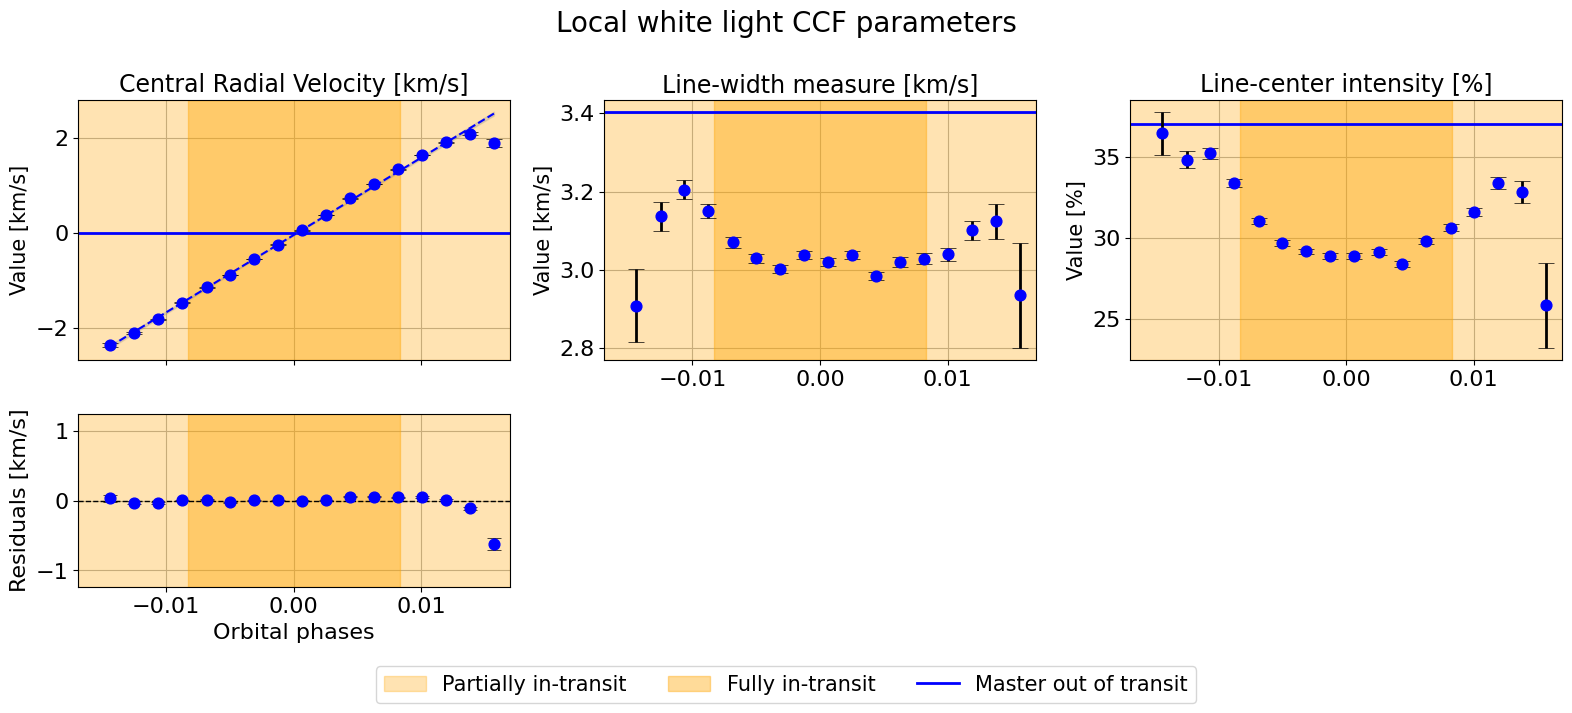

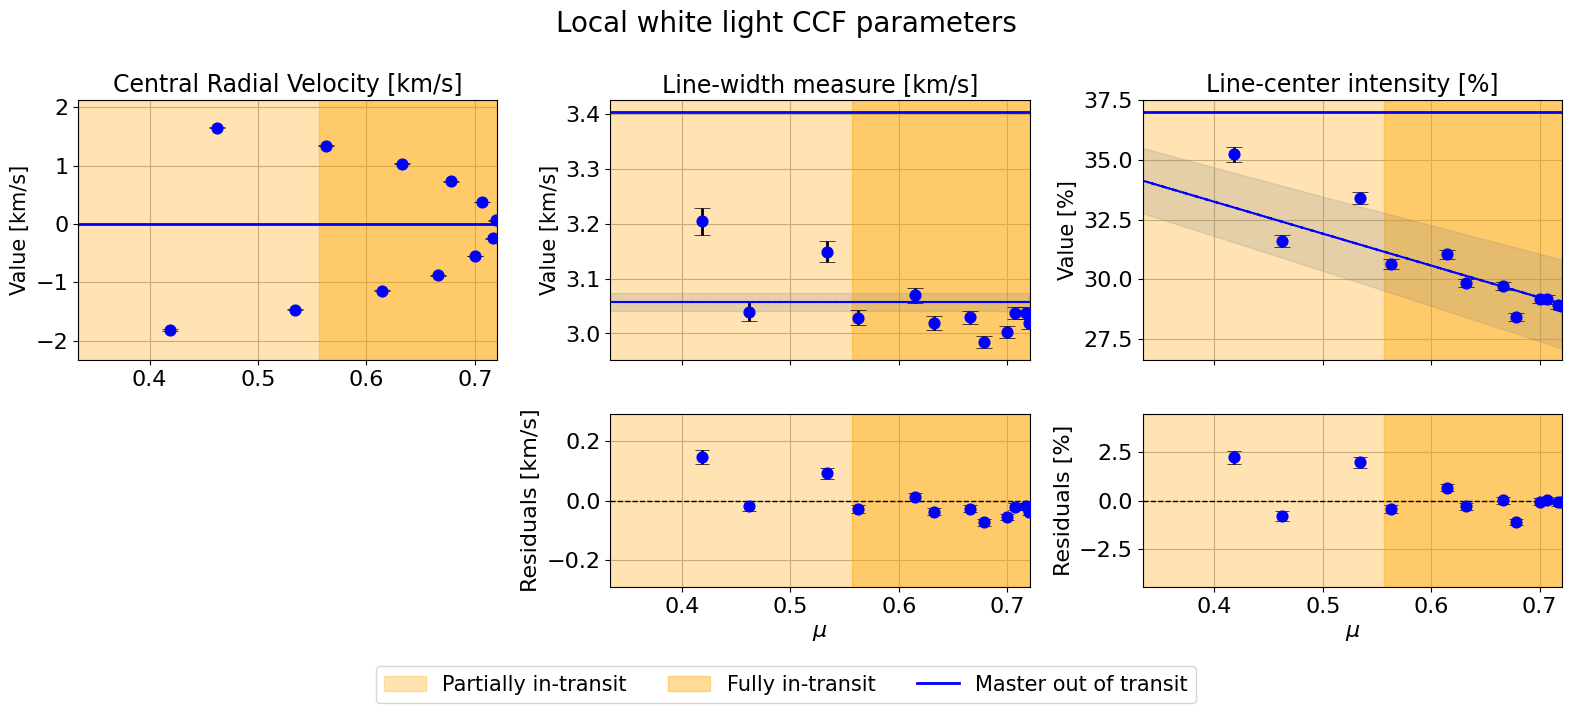

In [14]:
hecate.plot_local_params(indices_final, local_params, master_params, 
                         suptitle=r"Local white light CCF parameters",
                         linear_fit_pairs=[("phases", 0), ("mu", 1), ("mu", 2)])